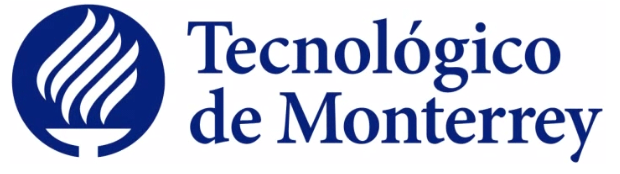

Tecnológico de Monterrey - Campus Santa Fe

**Curso:** Inteligencia artificial avanzada para la ciencia de datos II (Gpo 101)

**Alumno:** Pedro Mauri Mtz - A01029143

**Profesor:** Esteban Castillo Juarez

# Examen final - Natural Language Processing

In [3]:
"""
Pedro Mauri Mtz - A01029143
Examen Final del módulo de NLP
"""

'\nPedro Mauri Mtz - A01029143\nExamen Final del módulo de NLP\n'

## Análisis de texto

**Libro elegido:** The Count of Montecristo

### Imports

In [4]:
import numpy as np
import re
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import spacy
import string

import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet as wn

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.cluster import KMeans

# !pip install gensim
from gensim.models import Word2Vec

import torch
from transformers import AutoTokenizer, AutoModel

import networkx as nx

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\pedro\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
c:\Users\pedro\Documents\Documentos Tec\Semestre_7_Concentracion_IA\Advanced_IA_Implementation\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read book's texts

In [5]:
# Leer archivo y guardarlo en 'raw_text'

text_path = Path("../Datasets/the_count_of_montecristo.txt")

with open(text_path, "r", encoding="utf-8", errors="ignore") as file:
    raw_text = file.read()

In [6]:
# Recortar cabecera y pie de Gutenberg

start = re.search(r"\*\*\* START OF THE PROJECT GUTENBERG EBOOK THE COUNT OF MONTE CRISTO \*\*\*", raw_text)
end   = re.search(r"\*\*\* END OF THE PROJECT GUTENBERG EBOOK THE COUNT OF MONTE CRISTO \*\*\*", raw_text)
text = raw_text[start.end():end.start()] if start and end else raw_text

In [7]:
# Tokenización
word_pattern = re.compile(r"\b\w[\w'-]*\b", re.UNICODE)

# Tokenización manteniendo las mayúsculas
words = word_pattern.findall(text)

# Tokenización con minúsculas
words_lower = [w.lower() for w in words]

In [8]:
max_len = max(len(word) for word in words[:9])

for (word, word_low) in zip(words[:9], words_lower[:9]):
  print(f"{word:<{max_len}} | {word_low:<{max_len}}")

THE       | the      
COUNT     | count    
OF        | of       
MONTE     | monte    
CRISTO    | cristo   
by        | by       
Alexandre | alexandre
Dumas     | dumas    
père      | père     


### 1. Ley de Zipf

Genere una visualización utilizando la ley de Zipf para ver la calidad del corpus a analizar. Justifique la calidad del corpus en base al grafico presentado.

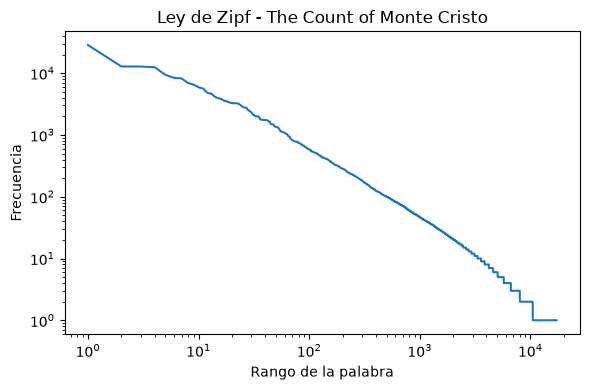

In [9]:
freq_all = Counter(words_lower)
sorted_freqs = [frequency for word, frequency in freq_all.most_common()]

ranks = np.arange(1, len(sorted_freqs) + 1)
frequencies = np.array(sorted_freqs)

plt.figure(figsize = (6, 4))
plt.loglog(ranks, frequencies)
plt.xlabel("Rango de la palabra")
plt.ylabel("Frecuencia")
plt.title("Ley de Zipf - The Count of Monte Cristo")
plt.tight_layout()
plt.show()

### 2-5. Número de cantidad de tokens que...

- Contar el número total de palabras en el corpus.
- Contar la cantidad de palabras únicas en el texto.
- Contar el número de palabras que comienzan con letras mayúsculas.
- Contar el número de palabras que comienzan con letras minúsculas.

In [10]:
print(f"Número total de palabras: {len(words)}")
print(f"Número total de palabras ÚNICAS: {len(set(words))}")

upper_initial = 0
lower_initial = 0

for word in words:
    if word[0].isalpha():
        if word[0].isupper():
            upper_initial += 1
        elif word[0].islower():
            lower_initial += 1

print(f"Número total de palabras que comienzan con mayúscula: {upper_initial}")
print(f"Número total de palabras que comienzan con minúscula: {lower_initial}")


Número total de palabras: 465870
Número total de palabras ÚNICAS: 18454
Número total de palabras que comienzan con mayúscula: 53035
Número total de palabras que comienzan con minúscula: 410743


En el caso de este libro tenemos;
- 465,870 Palabras en total.
- 18,454 Palabras únicas en total.

Lo que implica que no hay tantas palabras distintas entre sí, pero se repiten mucho. Lo más probable es que los nombres de los personajes sean unos de los tokens que más se repiten.

### 6. Frecuencia de las stopwords

Contar la frecuencia de las palabras cerradas (stopwords) en el corpus.

In [11]:
english_stopwords = {
    "a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as",
    "at", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "could",
    "did", "do", "does", "doing", "down", "during", "each", "few", "for", "from", "further", "had", "has",
    "have", "having", "he", "her", "here", "hers", "herself", "him", "himself", "his", "how","i", "if",
    "in", "into", "is", "it", "its", "itself", "just", "me", "more", "most", "my", "myself", "no", "nor",
    "not", "now", "of", "off", "on", "once", "only", "or", "other", "our", "ours", "ourselves", "out", "over",
    "own", "same", "she", "should", "so", "some", "such", "than", "that", "the", "their", "theirs", "them",
    "themselves", "then", "there", "these", "they", "this", "those", "through", "to", "too", "under", "until",
    "up", "very", "was", "we", "were", "what", "when", "where", "which", "while", "who", "whom", "why", "with",
    "would","you","your","yours","yourself","yourselves"
}

stopword_counts = Counter(word for word in words_lower if word in english_stopwords)
total_stopwords = sum(stopword_counts.values())

print(f"Cantidad total de stopwords: {total_stopwords}")
print(f"Top 10 stopwords: {stopword_counts.most_common(10)}")

Cantidad total de stopwords: 240175
Top 10 stopwords: [('the', 28442), ('to', 12816), ('of', 12776), ('and', 12462), ('a', 9408), ('i', 8388), ('you', 8213), ('he', 6943), ('in', 6510), ('his', 5908)]


### 7. Palabras más comunes

Identificar y contar las palabras más comunes en el texto.

In [12]:
content_words = [word for word in words_lower if word not in english_stopwords]
freq_content = Counter(content_words)

print(freq_content.most_common(20))

[('said', 3492), ('will', 1995), ('s', 1750), ('one', 1496), ('count', 1487), ('man', 1410), ('monte', 1133), ('cristo', 1127), ('m', 1103), ('villefort', 1090), ('de', 1036), ('yes', 983), ('well', 949), ('danglars', 919), ('know', 846), ('young', 796), ('albert', 780), ('two', 777), ('morrel', 776), ('madame', 767)]


Entre las palabras con mayor frecuencia tenemos "said" y "will".
Seguramente 'said' se usaba cada vez que el protagonista recordaba algo dicho por sus traidores, o cada vez que se terminaba un dialogo de un personaje. Mientras que seguramente 'will' se usaba cada vez que el protagonista mencionaba uno de sus objetivos a cumplir.

Las siguientes 5 palabras más frecuentes son nombres de los personajes, lo cual suma a la teoría mencionada anteriormente (los nombres de los personajes se repiten mucho).

### 8. Nombres propios

Identificar y contar la frecuencia de nombres propios en el corpus.

In [13]:
proper_name_counts = Counter()

for sent in re.split(r'[.!?]+', text):
    sent = sent.strip()

    if not sent:
        continue

    tokens = word_pattern.findall(sent)

    for idx, token in enumerate(tokens):
        if token[0].isupper() and not token.isupper():
            if idx == 0:
                continue
            proper_name_counts[token] += 1

print(proper_name_counts.most_common(20))


[('Cristo', 1126), ('Monte', 955), ('Villefort', 949), ('Danglars', 721), ('Albert', 626), ('Dantès', 580), ('Valentine', 531), ('Morrel', 522), ('Madame', 452), ('Franz', 428), ('Morcerf', 366), ('Caderousse', 359), ('Edmond', 259), ('Paris', 258), ('Count', 237), ('Maximilian', 234), ('Andrea', 222), ('Mercédès', 214), ('Beauchamp', 203), ('God', 184)]


### 9 - 10. Oraciones

- Contar el número total de oraciones en el corpus.
- Calcular la longitud promedio de las oraciones.

In [14]:
parts = re.split(r'([.!?])', text)
sentences = []
sentences_with_punct = []

for i in range(0, len(parts) - 1, 2):
    sent = parts[i].strip()
    punct = parts[i + 1]

    if sent:
        sentences.append(sent)
        sentences_with_punct.append((sent, punct))

num_sentences = len(sentences)

sentence_lengths = [len(word_pattern.findall(s)) for s in sentences]
avg_sentence_len = sum(sentence_lengths) / len(sentence_lengths)

print(f"Cantidad total de oraciones: {num_sentences}")
print(f"Longitud promedio (palabras por oración): {avg_sentence_len}")


Cantidad total de oraciones: 27884
Longitud promedio (palabras por oración): 16.707430784679385


### 11. Signos de puntuación

Contar cuántas veces aparecen cada uno de los signos de puntuación.

In [15]:
punct_chars = list(".,;:!?\"'—-()[]")

punct_counts = Counter(char for char in text if char in punct_chars)

for char, count in punct_counts.items():
    print(repr(char), ":", count)

'[' : 33
']' : 33
'.' : 21726
'—' : 2771
':' : 302
'-' : 2153
',' : 45090
';' : 5992
'?' : 4609
'!' : 1762
'(' : 101
')' : 101


### 12. Tokens más largos

Encontrar las palabras más largas en el texto.

In [16]:
clean_words = [re.sub(r"^[^A-Za-z0-9]+|[^A-Za-z0-9]+$", "", word) for word in words]
clean_words = [word for word in clean_words if word]

max_len = max(len(word) for word in clean_words)
longest_words = sorted({word.lower() for word in clean_words if len(word) == max_len})

print(f"Longitud máxima: {max_len}")
print(f"Palabras con esa longitud: {longest_words}")


Longitud máxima: 26
Palabras con esa longitud: ['chastity-modesty-innocence']


### 13. Número de preguntas

Contar el número de oraciones interrogativas.

In [17]:
num_questions = sum(1 for sentence, punctiation in sentences_with_punct if punctiation == "?")

print(f"Número de oraciones interrogativas (con ?): {num_questions}")

Número de oraciones interrogativas (con ?): 4607


### 14. Nombres de entidades, personas y lugares

Identificar y extraer entidades como nombres de personas, lugares y organizaciones.

In [19]:
nlp = spacy.load("en_core_web_sm")

doc = nlp(text[:200000])

ent_max_len = max(len(ent) for ent in doc.ents)

for ent in doc.ents:
    print(f"{ent.text:<{ent_max_len}} | {ent.label_}")

Alexandre Dumas | PERSON
Contents


 VOLUME ONE | ORG
Chapter 1 | LAW
The Arrival
Chapter 2 | FAC
Chapter 3 | LAW
Catalans  | NORP
Chapter 4 | LAW
Chapter 5 | LAW
Chapter 6 | LAW
Chapter 7 | LAW
Examination | ORG
Chapter 8 | LAW
Chapter 9 | LAW
Evening   | TIME
Chapter 10 | LAW
The King’s Closet | ORG
Tuileries | ORG
Chapter 11 | LAW
Chapter 12 | LAW
Chapter 13 | LAW
The Hundred Days | DATE
Chapter 14 | LAW
Two       | CARDINAL
Chapter 15 | LAW
34        | CARDINAL
27        | CARDINAL
Chapter 16 | LAW
Learned Italian | NORP
Chapter 17 | LAW
Chapter 18 | LAW
Chapter 19 | LAW
Chapter 20 | LAW
The Cemetery of the Château d’If
Chapter 21 | WORK_OF_ART
The Island of Tiboulen
Chapter | LOC
Chapter 23 | LAW
The Island of Monte Cristo | LOC
Chapter 24 | LAW
The Secret Cave
Chapter 25 | WORK_OF_ART
Chapter 26 | LAW
The Pont  | ORG
Gard Inn
Chapter | PERSON
TWO       | CARDINAL
Chapter 28 | LAW
Chapter 29 | LAW
The House of Morrel & Son
Chapter 30 | ORG
Fifth     | ORDINAL
Chapter 31 | LAW
Ital

### 15. Citas

Encontrar y extraer todas las citas directas (entre comillas) en el corpus.

In [20]:
quotes_curly = re.findall(r'“([^”]+)”', text)
quotes_straight = re.findall(r'"([^"]+)"', text)

all_quotes = quotes_curly + quotes_straight

print(f"Número total de citas: {len(all_quotes)}")

print("Primeras 5 citas:")
for quote in all_quotes[:5]:
    print(f"- {quote.strip()[:120]} ...")

Número total de citas: 15186
Primeras 5 citas:
- Ah, is it you, Dantès? ...
- What’s the
matter? and why have you such an air of sadness aboard? ...
- A great misfortune, M. Morrel, ...
- a great
misfortune, for me especially! Off Civita Vecchia we lost our brave
Captain Leclere. ...
- And the cargo? ...


### 16. Preguntas

Detectar y extraer preguntas en el texto.

In [21]:
questions = [sentence for (sentence, punctuation) in sentences_with_punct if punctuation == "?"]

print(f"Total de preguntas: {len(questions)}")
for question in questions[:5]:
    print(f"- {question.strip()[:120]}?...")


Total de preguntas: 4607
- “Ah, is it you, Dantès?...
- “What’s the
matter?...
- and why have you such an air of sadness aboard?...
- ”

“And the cargo?...
- But poor Captain Leclere——”

“What happened to him?...


### 17. Sinónimos

Identificar palabras que tienen más de un significado.

In [22]:
candidate_words = [word for word, candidate in freq_content.most_common(200)]

polysemous = []

for word in candidate_words:
    syns = wn.synsets(word)
    if len(syns) >= 2:
        polysemous.append((word, len(syns)))

polysemous = sorted(polysemous, key=lambda x: -x[1])

for i in range(0, 20):
  print(polysemous[i])


('made', 52)
('make', 51)
('light', 47)
('give', 45)
('take', 44)
('gave', 44)
('taken', 44)
('took', 42)
('head', 42)
('right', 36)
('go', 35)
('going', 34)
('place', 32)
('went', 30)
('return', 29)
('saw', 28)
('back', 28)
('turned', 28)
('good', 27)
('see', 25)


### 18. Bigramas and trigramas

Encontrar los bigramas, trigramas y cuatrigramas más relevantes en el texto.

In [23]:
def ngrams(tokens, n):
    return zip(*[tokens[i:] for i in range(n)])

def top_ngrams(tokens, n, top=20):
    counts = Counter()

    for gram in ngrams(tokens, n):
        if any(word not in english_stopwords for word in gram):
            counts[gram] += 1

    return counts.most_common(top)

top_bigrams = top_ngrams(words_lower, 2, 20)
top_trigrams = top_ngrams(words_lower, 3, 20)
top_fourgrams = top_ngrams(words_lower, 4, 20)

print(f"Bigrama: {top_bigrams[:5]}")
print(f"Trigrama: {top_trigrams[:5]}")
print(f"Cuatrigrama: {top_fourgrams[:5]}")


Bigrama: [(('the', 'count'), 1228), (('monte', 'cristo'), 1127), (('said', 'the'), 786), (('the', 'young'), 530), (('i', 'will'), 492)]
Trigrama: [(('the', 'young', 'man'), 306), (('said', 'monte', 'cristo'), 282), (('madame', 'de', 'villefort'), 230), (('one', 'of', 'the'), 211), (('m', 'de', 'villefort'), 211)]
Cuatrigrama: [(('count', 'of', 'monte', 'cristo'), 147), (('the', 'count', 'of', 'monte'), 130), (('at', 'the', 'end', 'of'), 69), (('at', 'the', 'same', 'time'), 62), (('in', 'the', 'midst', 'of'), 52)]


### 19. Temas y Topicos recurrentes

Identificar cuáles son los temas/tópicos más recurrentes en el texto.

## Procesamiento de Texto

El libro del Conde de Montecristo no lo he leido todavía, sin embargo conozco la historia por las películas y videos. El libro tiene un desarrollo profundo en diversos personajes, el protagonista pasa por tantas experiencias que lo hacen cambiar constantemente a algo irreconocible a su versión anterior. Edmond es traicionado por su mejor amigo, robandole el amor de su vida y su libertad; así que el vuelve con una nueva identidad en busca de venganza.

#### Venganza y justicia:

Estos temas estas asociados principalmente a los tokens;  Edmond, count, Montecristo, justice, crime, etc. Ya que el personaje principal desarrolla su historia a estos valores.

#### Identidad, traición y conspiración:

Estos temas estan más relacionados con los nombres de personajes traidores o aliados del protagonista: Danglars, Villefort, Caderousse, Morcerf, etc.

#### Familia, amor y sacrificio:

Relacionados con personajes como Mercédès, Valentine, Maximilian, Morrel, Albert. Los cuales estan asociados a tramas familiares y románticas por sus arcos personales.

#### Contexto social y lugares:

Algunos lugares recurrentes en el cuento son: Marseilles, Paris, Rome, Chateau d’If, Italy, que muestran los escenarios políticos y sociales.

### 20. Bag of Words y TF-IDF

Construir una representación de tipo Bag of Words y TF-IDF  y comparar cuales son las palabras mas relevantes para ambas sin tomar en cuenta las palabras cerradas.

In [24]:
docs = sentences
stopword_list = list(english_stopwords)

In [25]:
# ----- Bag of Words -----

bow_vectorizer = CountVectorizer(stop_words = stopword_list)
X_bow = bow_vectorizer.fit_transform(docs)

bow_vocab = np.array(bow_vectorizer.get_feature_names_out())
bow_counts = np.asarray(X_bow.sum(axis = 0)).ravel()

top_bow_idx = bow_counts.argsort()[::-1][:20]
top_bow = list(zip(bow_vocab[top_bow_idx], bow_counts[top_bow_idx]))

print("Top 20 palabras (Bag of Words, sin stopwords):")
for w, c in top_bow:
    print(f"{w:15} -> {c}")


Top 20 palabras (Bag of Words, sin stopwords):
said            -> 3492
will            -> 2002
one             -> 1509
count           -> 1487
man             -> 1413
monte           -> 1135
cristo          -> 1128
villefort       -> 1090
de              -> 1044
well            -> 992
yes             -> 983
danglars        -> 919
know            -> 846
two             -> 797
young           -> 796
albert          -> 780
morrel          -> 776
madame          -> 767
replied         -> 739
see             -> 737


In [26]:
# ----- TF-IDF -----

tfidf_vectorizer = TfidfVectorizer(stop_words = stopword_list)
X_tfidf = tfidf_vectorizer.fit_transform(docs)

tfidf_vocab = np.array(tfidf_vectorizer.get_feature_names_out())
tfidf_scores = np.asarray(X_tfidf.mean(axis = 0)).ravel()

top_tfidf_idx = tfidf_scores.argsort()[::-1][:20]
top_tfidf = list(zip(tfidf_vocab[top_tfidf_idx], tfidf_scores[top_tfidf_idx]))

print("\nTop 20 palabras (TF-IDF, sin stopwords):")
for w, s in top_tfidf:
    print(f"{w:15} -> {s:.4f}")



Top 20 palabras (TF-IDF, sin stopwords):
said            -> 0.0263
yes             -> 0.0155
will            -> 0.0147
count           -> 0.0120
well            -> 0.0105
man             -> 0.0100
villefort       -> 0.0100
one             -> 0.0099
monte           -> 0.0098
cristo          -> 0.0097
de              -> 0.0095
know            -> 0.0091
danglars        -> 0.0086
asked           -> 0.0083
morrel          -> 0.0081
replied         -> 0.0075
oh              -> 0.0073
albert          -> 0.0072
see             -> 0.0072
madame          -> 0.0069


### 21. Entrenar embeddings

Entrenar un modelo de embeddings y analizar qué palabras presentan mayor similitud semántica con el término clave que ustedes consideren del corpus.

In [27]:
# Tokenización de cada oración en lista de palabras en minúsculas
sent_tokens = [word_pattern.findall(sentence.lower()) for sentence in sentences]

# Entrenamos Word2Vec
w2v_model = Word2Vec(
    sentences = sent_tokens,
    vector_size = 100,
    window = 5,
    min_count = 5,
    workers = 4,
    sg = 1  # 1 = skip-gram, 0 = CBOW
)

# PALABRA CLAVE:
keyword = "revenge"  # montecristo, count, dantes, revenge

if keyword in w2v_model.wv:
    print(f"===== Palabras más similares a '{keyword}' =====")

    for w, sim in w2v_model.wv.most_similar(keyword, topn = 15):
        print(f"{w:15} -> {sim:.3f}")
else:
    print(f"===== La palabra '{keyword}' no está en el vocabulario del modelo =====")


===== Palabras más similares a 'revenge' =====
fail            -> 0.956
continue        -> 0.956
perish          -> 0.955
repay           -> 0.955
responsible     -> 0.954
attribute       -> 0.954
obey            -> 0.953
pledged         -> 0.952
betray          -> 0.952
fulfil          -> 0.950
protect         -> 0.950
services        -> 0.949
goodness        -> 0.949
deprive         -> 0.949
oppose          -> 0.949


### 22. Generar embeddings

Generar embeddings contextuales (BERT, por ejemplo) para varias oraciones del corpus y analizar cómo cambia el vector de una misma palabra cuando aparece en contextos diferentes.

In [28]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

# 'target_word'
target_word = "revenge"

# Buscamos oraciones que contengan la palabra 'target_word'
example_sentences = [sentence for sentence in sentences if target_word in sentence.lower()]

# 3 ejemplos
example_sentences = example_sentences[:3]
for i, s in enumerate(example_sentences):
    print(f"\n=== Ejemplo {i + 1} ===")
    print(s)

# Tokenización
inputs = tokenizer(example_sentences, return_tensors = "pt", padding = True, truncation = True)

with torch.no_grad():
    outputs = bert_model(**inputs)

last_hidden = outputs.last_hidden_state

# Obtenemos un vector para la 'target_word' en cada oración
def get_token_embedding(sentence_idx, word, inputs, hidden_states):
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][sentence_idx])
    word = word.lower()

    indices = [i for i, tok in enumerate(tokens) if word in tok] # match simple

    if not indices:
        # fallback: usamos embedding [CLS]
        return hidden_states[sentence_idx, 0].numpy()

    vecs = hidden_states[sentence_idx, indices, :].mean(dim = 0)

    return vecs.numpy()



embs = []

for i in range(len(example_sentences)):
    vec = get_token_embedding(i, target_word, inputs, last_hidden)
    embs.append(vec)

# Similaridad de coseno entre los contextos
def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

print(f"\n===== Similaridad de coseno entre los contextos de {target_word} =====")

for i in range(len(embs)):
    for j in range(i + 1, len(embs)):
        sim = cosine(embs[i], embs[j])

        print(f"Contexto {i + 1} vs {j + 1}: {sim:.3f}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 744.95it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Ejemplo 1 ===
“I
understand you, Fernand; you would be revenged on him because I do not
love you; you would cross your Catalan knife with his dirk

=== Ejemplo 2 ===
”

0056m



“Yes; but one gets out of prison,” said Caderousse, who, with what
sense was left him, listened eagerly to the conversation, “and when one
gets out and one’s name is Edmond Dantès, one seeks revenge——”

“What matters that

=== Ejemplo 3 ===
”

“Very good,” resumed Danglars; “now your revenge looks like common
sense, for in no way can it revert to yourself, and the matter will
thus work its own way; there is nothing to do now but fold the letter
as I am doing, and write upon it, ‘To the king’s attorney,’ and that’s
all settled

===== Similaridad de coseno entre los contextos de revenge =====
Contexto 1 vs 2: 0.671
Contexto 1 vs 3: 0.618
Contexto 2 vs 3: 0.770


### 23. Comparación de Bag of Words, TF-IDF y embeddings

Comparar la capacidad de Bag of Words, TF-IDF y embeddings para capturar el significado semántico del texto, utilizando ejemplos del corpus.

#### **BoW:**

- Representa solo frecuencias (cuantas veces aparece cada palabra) de palabras.
Pero pierde orden y contexto; lo que implica que no distingue significados diferentes de la misma palabra.

#### **TF-IDF:**

- Similar a BoW, pero penaliza palabras muy frecuentes y resalta términos “típicos” de ciertos documentos.
Es deicr, tiene el objetibo de medir la importancia de un término en un texto. Sin embargo, no puede comprender contexto del documento.

#### **Embeddings clásicos (Word2Vec):**

- Consiste en colocar los tokens en un espacio donde la distancia refleja similitud semántica.
Sin embargo no distingue contextos o significados de los tokens, pero sí agrupa palabras relacionadas.

#### **Embeddings contextuales (BERT):**

- Representación del token + su contexto: La misma palabra tiene vectores diferentes en oraciones distintas.
Esta representación vectorial es la que mejor captura matices semánticos y polisemia (Especialmente útil en un texto literario como este).

### 24. Evaluación de desempeño

Evaluar cuál representación de las vistas en clase permite un mejor desempeño en una tarea sencilla de clasificación, como identificar oraciones interrogativas.

In [29]:
# Dataset de oraciones y etiquetas
texts = []
labels = []

for sent, punctuation in sentences_with_punct:
    texts.append(sent)
    labels.append(1 if punctuation == "?" else 0)

# Limpiar signos de puntuación
def remove_punctuation(s):
    return s.translate(str.maketrans("", "", string.punctuation))

texts_clean = [remove_punctuation(s) for s in texts]


idx_q = [i for i, y in enumerate(labels) if y == 1]
idx_nq = [i for i, y in enumerate(labels) if y == 0]

min_size = min(len(idx_q), len(idx_nq))
idx_q = idx_q[:min_size]
idx_nq = idx_nq[:min_size]

indices = idx_q + idx_nq
texts_bal = [texts_clean[i] for i in indices]
labels_bal = [labels[i] for i in indices]

In [30]:
# Split datasets (train, test)
X_train, X_test, y_train, y_test = train_test_split(
    texts_bal, labels_bal, test_size = 0.3, random_state = 42, stratify = labels_bal
)

In [31]:
# Logistic Regression Model's train and test function
def eval_representation(vectorizer, X_train, X_test, y_train, y_test, name):
    Xtr = vectorizer.fit_transform(X_train)
    Xte = vectorizer.transform(X_test)

    clf = LogisticRegression(max_iter = 1000)
    clf.fit(Xtr, y_train)
    y_pred = clf.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Model: {name} => Accuracy = {acc:.3f} | F1 = {f1:.3f}")

In [32]:
# BoW
bow_vec = CountVectorizer(stop_words = stopword_list)
eval_representation(bow_vec, X_train, X_test, y_train, y_test, "BoW")

# TF-IDF
tfidf_vec = TfidfVectorizer(stop_words = stopword_list)
eval_representation(tfidf_vec, X_train, X_test, y_train, y_test, "TF-IDF")

Model: BoW => Accuracy = 0.797 | F1 = 0.809
Model: TF-IDF => Accuracy = 0.796 | F1 = 0.798


### 25. Grafo de coocurrencia

Visualizar en un grafo de coocurrencia los puntos donde cambia los temas a lo largo del texto.

In [33]:
# Top palabras 100 del texto -> nodos
top_content_words = [w for w, c in freq_content.most_common(100)]
top_content_set = set(top_content_words)

def build_cooccurrence_graph(segment_sentences, vocab_set, pattern):
    G = nx.Graph()

    for sent in segment_sentences:
        tokens = [t.lower() for t in pattern.findall(sent)]
        tokens = [t for t in tokens if t in vocab_set]
        # sin repeticiones en la misma oración
        tokens = sorted(set(tokens))

        for i in range(len(tokens)):
            for j in range(i + 1, len(tokens)):
                u, v = tokens[i], tokens[j]
                if G.has_edge(u, v):
                    G[u][v]["weight"] += 1
                else:
                    G.add_edge(u, v, weight = 1)
    return G

# Dividir grafo en 4 segmentos
num_sents = len(sentences)
segment_size = num_sents // 4
segments = [
    sentences[0:segment_size],
    sentences[segment_size:2 * segment_size],
    sentences[2 * segment_size:3 * segment_size],
    sentences[3 * segment_size:]
]

graphs = [build_cooccurrence_graph(seg, top_content_set, word_pattern) for seg in segments]

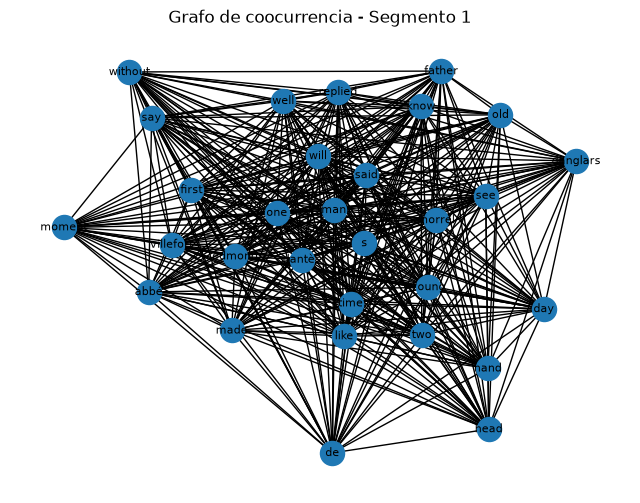

In [34]:
# Visualización del grafo del primer segmento
i = 0 # (0-3) Para iterar entre los 4 segmentos
G0 = graphs[i]
deg = dict(G0.degree())
top_nodes = sorted(deg, key = deg.get, reverse = True)[:30]

plt.figure(figsize = (8, 6))
pos = nx.spring_layout(G0, k = 0.5, iterations = 50)

nx.draw_networkx_nodes(G0, pos, nodelist = top_nodes)
nx.draw_networkx_edges(G0, pos, edgelist = [(u, v) for u, v in G0.edges() if u in top_nodes and v in top_nodes])
nx.draw_networkx_labels(G0, pos, labels = {n: n for n in top_nodes}, font_size = 8)

plt.title(f"Grafo de coocurrencia - Segmento {i + 1}")
plt.axis("off")
plt.show()

### 26. Métricas de centralidad

Aplicar las métricas de centralidad vistas en clase para determinar topicos relevantes sobre el grafo del punto previo.
  - Degree
  - Closeness
  - Betweenness

In [35]:
# Unir todos los segmentos en un solo grafo
G_all = build_cooccurrence_graph(sentences, top_content_set, word_pattern)

n_nodes = G_all.number_of_nodes()
k_sample = min(200, n_nodes)

# Degree centrality
deg_c = nx.degree_centrality(G_all)

# Closeness centrality
clo_c = nx.closeness_centrality(G_all)

# Betweenness centrality
bet_c = nx.betweenness_centrality(G_all, k = k_sample, seed = 42)

def top_centrality(cent_dict, name, k = 15):
    print(f"\nTop {k} nodos por {name}:")

    for node, val in sorted(cent_dict.items(), key = lambda x: -x[1])[:k]:
        print(f"{node:15} -> {val:.4f}")

top_centrality(deg_c, "Degree")
top_centrality(clo_c, "Closeness")
top_centrality(bet_c, "Betweenness")



Top 15 nodos por Degree:
count           -> 1.0000
cristo          -> 1.0000
monte           -> 1.0000
one             -> 1.0000
s               -> 1.0000
house           -> 1.0000
de              -> 1.0000
villefort       -> 1.0000
come            -> 1.0000
like            -> 1.0000
old             -> 1.0000
another         -> 1.0000
made            -> 1.0000
man             -> 1.0000
young           -> 1.0000

Top 15 nodos por Closeness:
count           -> 1.0000
cristo          -> 1.0000
monte           -> 1.0000
one             -> 1.0000
s               -> 1.0000
house           -> 1.0000
de              -> 1.0000
villefort       -> 1.0000
come            -> 1.0000
like            -> 1.0000
old             -> 1.0000
another         -> 1.0000
made            -> 1.0000
man             -> 1.0000
young           -> 1.0000

Top 15 nodos por Betweenness:
count           -> 0.0001
cristo          -> 0.0001
monte           -> 0.0001
one             -> 0.0001
s               -> 0.0001
hous

### 27. Propuesta para agrupar texto

Proponer alguna tecnica de machine learning para agrupar texto (k-means, hearchical clustering, etc). hablando del proposito de esto para entender un corpus de datos.

Modelo de clustering elegido: K Means

In [36]:
# Vectorizamos oraciones con TF-IDF
vectorizer_topics = TfidfVectorizer(stop_words = stopword_list, max_features = 3000)
X_topics = vectorizer_topics.fit_transform(sentences)

# Clusterización
k = 5
kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
clusters = kmeans.fit_predict(X_topics)

terms = vectorizer_topics.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

# Print de contenido de clusters
for i in range(k):
    top_terms = [terms[ind] for ind in order_centroids[i, :25]]
    print(f"\nCluster {i + 1}:")
    print(", ".join(top_terms))



Cluster 1:
oh, yes, said, cried, sir, heavens, exclaimed, excellency, father, can, nothing, count, will, god, tell, enough, know, shall, dear, monsieur, replied, monte, much, cristo, love

Cluster 2:
will, one, count, well, man, know, danglars, replied, see, chapter, say, morrel, dantès, father, two, shall, monte, cristo, time, young, like, albert, must, can, tell

Cluster 3:
said, yes, cristo, monte, count, well, albert, caderousse, sir, danglars, man, morrel, ah, will, come, valentine, beauchamp, young, know, dear, replied, see, franz, us, andrea

Cluster 4:
asked, morrel, cristo, monte, count, danglars, albert, beauchamp, abbé, franz, valentine, debray, young, man, villefort, caderousse, president, well, tone, château, baroness, avrigny, renaud, countess, madame

Cluster 5:
de, villefort, madame, morcerf, méran, saint, said, cristo, monte, mademoiselle, valentine, boville, room, danglars, house, replied, will, noirtier, king, albert, château, renaud, cried, one, father


Al realizar una clusterización los tokens del texto aún sin etiquetas; nos permite descubrir temas ocultos, al encontrar similitudes entre los tokens.

Se pueden explorar capítulos o partes del libro análizado que traten de temas similares.